# Question 4: Network Robustness — Node Deletion

We study how networks respond to node removal by measuring:
- **Characteristic path length** $L$ (on the largest connected component)
- **Giant cluster size** $S$ (fraction of nodes in the largest component)
- **Average fragment size** $\langle s \rangle$ (mean size of non-giant components)

Two deletion strategies:
- **Random failure**: remove nodes at random
- **Targeted attack**: remove highest-degree nodes first

We test on Erdős–Rényi (random), Barabási-Albert (scale-free), and a real-world network.


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import urllib.request
import gzip
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("Libraries imported successfully.")
print(f"NetworkX version: {nx.__version__}")

Libraries imported successfully.
NetworkX version: 3.6.1


## Helper Functions

Functions to compute $S$, $\langle s \rangle$, and $L$ after each round of node removal.

In [3]:
def get_giant_component(G):
    """Return subgraph of the largest connected component."""
    if G.number_of_nodes() == 0:
        return G
    if nx.is_directed(G):
        components = list(nx.weakly_connected_components(G))
    else:
        components = list(nx.connected_components(G))
    largest = max(components, key=len)
    return G.subgraph(largest).copy()


def compute_S(G, n0):
    """Giant cluster size normalized by original n."""
    if G.number_of_nodes() == 0:
        return 0.0
    if nx.is_directed(G):
        components = list(nx.weakly_connected_components(G))
    else:
        components = list(nx.connected_components(G))
    return max(len(c) for c in components) / n0


def compute_avg_small_s(G, n0):
    """
    Average size of non-giant components using the percolation-theory formula:
        <s> = sum(s^2 * n_s) / N  =  sum(s_i^2 for each non-giant cluster i) / n0
    This correctly peaks near the percolation threshold (as in Albert et al. 2000).
    The old arithmetic-mean / n0 formula produced near-zero values with no visible peak.
    """
    if G.number_of_nodes() == 0:
        return 0.0
    if nx.is_directed(G):
        components = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
    else:
        components = sorted(nx.connected_components(G), key=len, reverse=True)
    if len(components) <= 1:
        return 0.0
    small_sizes = [len(c) for c in components[1:]]
    # Correct percolation-theory formula: sum of s^2 / N
    return sum(s**2 for s in small_sizes) / n0


def compute_path_length(G, sample_size=300):
    """Average shortest path length on the giant component (sampled for speed)."""
    giant = get_giant_component(G)
    if giant.number_of_nodes() <= 1:
        return 0.0

    nodes = list(giant.nodes())
    sources = random.sample(nodes, min(sample_size, len(nodes)))

    total = 0
    count = 0
    for src in sources:
        lengths = nx.single_source_shortest_path_length(giant, src)
        total += sum(lengths.values())
        count += len(lengths) - 1

    return total / count if count > 0 else 0.0

In [4]:
def simulate_node_deletion(G, strategy='random', f_steps=None, sample_size=300):
    """
    Progressively delete nodes and record S, <s>, and L at each step.

    strategy: 'random'   — remove nodes uniformly at random
              'targeted' — dynamically remove the highest-degree node at each step
                           (degrees recalculated after every removal, matching Albert et al.)
    """
    if f_steps is None:
        f_steps = np.arange(0.0, 0.81, 0.05)

    G_curr = G.copy()
    n0     = G.number_of_nodes()

    # For random: fix the removal order upfront (shuffle once)
    if strategy == 'random':
        removal_order = list(G.nodes())
        random.shuffle(removal_order)

    results_f = []
    results_S = []
    results_s = []
    results_L = []

    removed_so_far = 0

    for f in f_steps:
        target_removed = int(f * n0)

        if strategy == 'targeted':
            # Dynamically remove the current highest-degree node until we reach target
            while removed_so_far < target_removed and G_curr.number_of_nodes() > 0:
                # Pick highest-degree node in the current (modified) graph
                node = max(G_curr.degree(), key=lambda x: x[1])[0]
                G_curr.remove_node(node)
                removed_so_far += 1
        else:
            # Random: use the pre-shuffled list
            while removed_so_far < target_removed and removed_so_far < len(removal_order):
                node = removal_order[removed_so_far]
                if G_curr.has_node(node):
                    G_curr.remove_node(node)
                removed_so_far += 1

        S   = compute_S(G_curr, n0)
        s_a = compute_avg_small_s(G_curr, n0)
        L   = compute_path_length(G_curr, sample_size=sample_size)

        results_f.append(f)
        results_S.append(S)
        results_s.append(s_a)
        results_L.append(L)

    return {
        'f'    : np.array(results_f),
        'S'    : np.array(results_S),
        's_avg': np.array(results_s),
        'L'    : np.array(results_L)
    }

## Part (a): Random Node Deletion on a BA Network
Implementing random node deletion; measuring $L(f)$ and $S(f)$; calculate size of giant cluster.

Generate a BA network ($n=1000$, $m=3$) and progressively remove random nodes. Track $L(f)$ and $S(f)$.

In [5]:
# ============================================================
# Part (a): Generate BA Network and Apply Random Node Deletion
# ============================================================
N_BA = 1000   # Number of nodes
M_BA = 3      # Edges per new node

print(f"Generating Barabási-Albert network: n={N_BA}, m={M_BA}")
G_ba = nx.barabasi_albert_graph(N_BA, M_BA, seed=42)

print(f"Network created: {G_ba.number_of_nodes()} nodes, {G_ba.number_of_edges()} edges")
print(f"Average degree: {2 * G_ba.number_of_edges() / G_ba.number_of_nodes():.2f}")
print(f"Is connected: {nx.is_connected(G_ba)}")

# Define fraction steps
f_steps = np.arange(0.0, 0.81, 0.04)

print(f"\nRunning random node deletion simulation...")
res_ba_random = simulate_node_deletion(G_ba, strategy='random',
                                       f_steps=f_steps, sample_size=100)
print("Done.")

Generating Barabási-Albert network: n=1000, m=3
Network created: 1000 nodes, 2991 edges
Average degree: 5.98
Is connected: True

Running random node deletion simulation...
Done.


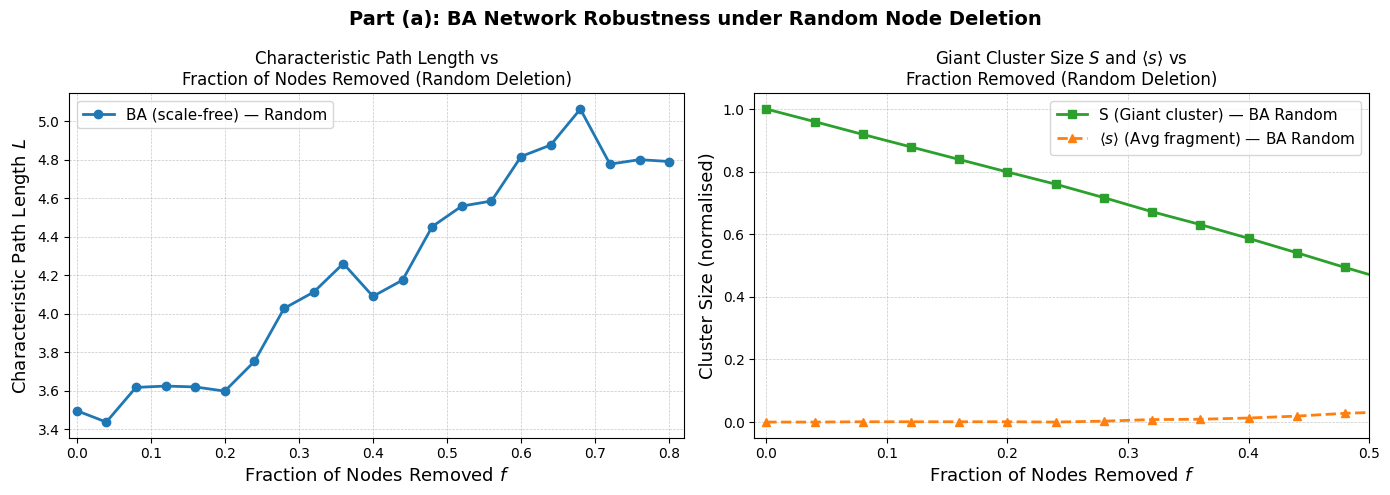

Figure saved: part_a_random_deletion_BA.png


In [6]:
# ============================================================
# Part (a): Plot L(f) and S(f) for random deletion on BA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Characteristic Path Length L(f) ---
axes[0].plot(res_ba_random['f'], res_ba_random['L'],
             'o-', color='#1f77b4', linewidth=2, markersize=6, label='BA (scale-free) — Random')
axes[0].set_xlabel('Fraction of Nodes Removed $f$', fontsize=13)
axes[0].set_ylabel('Characteristic Path Length $L$', fontsize=13)
axes[0].set_title('Characteristic Path Length vs\nFraction of Nodes Removed (Random Deletion)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
axes[0].set_xlim(-0.01, 0.82)

# --- Plot 2: Giant Cluster Size S(f) ---
axes[1].plot(res_ba_random['f'], res_ba_random['S'],
             's-', color='#2ca02c', linewidth=2, markersize=6, label='S (Giant cluster) — BA Random')
axes[1].plot(res_ba_random['f'], res_ba_random['s_avg'],
             '^--', color='#ff7f0e', linewidth=2, markersize=6, label='$\\langle s \\rangle$ (Avg fragment) — BA Random')
axes[1].set_xlabel('Fraction of Nodes Removed $f$', fontsize=13)
axes[1].set_ylabel('Cluster Size (normalised)', fontsize=13)
axes[1].set_title('Giant Cluster Size $S$ and $\\langle s \\rangle$ vs\nFraction Removed (Random Deletion)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
axes[1].set_xlim(-0.01, 0.5)

plt.suptitle('Part (a): BA Network Robustness under Random Node Deletion',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('part_a_random_deletion_BA.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: part_a_random_deletion_BA.png")

**Part (a) Observations:**
- The BA network is quite robust to random deletion — $S$ drops slowly since random removal is unlikely to hit the important hubs.
- $L$ stays fairly stable for small $f$ since the giant component stays well-connected.

---

## Part (b): Random vs Scale-Free — Random and Targeted Deletion
Comparing ER (random) and BA (scale-free) networks under (i) random failure and (ii) targeted attack. Correct implementation of both strategies + comparative analysis.



In [7]:
# ============================================================
# Part (b): Generate Erdős–Rényi Random Network
# ============================================================
N_ER = 1000  # Same number of nodes as BA

# Match the average degree of the BA network
avg_degree_BA = 2 * G_ba.number_of_edges() / G_ba.number_of_nodes()
p_ER = avg_degree_BA / (N_ER - 1)  # Edge probability for ER graph

print(f"BA network average degree: {avg_degree_BA:.2f}")
print(f"Erdős–Rényi edge probability p = {p_ER:.5f}")
print(f"Generating Erdős–Rényi network: n={N_ER}, p={p_ER:.5f}")

G_er = nx.erdos_renyi_graph(N_ER, p_ER, seed=42)
print(f"ER network: {G_er.number_of_nodes()} nodes, {G_er.number_of_edges()} edges")
print(f"ER average degree: {2 * G_er.number_of_edges() / G_er.number_of_nodes():.2f}")
print(f"ER is connected: {nx.is_connected(G_er)}")

BA network average degree: 5.98
Erdős–Rényi edge probability p = 0.00599
Generating Erdős–Rényi network: n=1000, p=0.00599
ER network: 1000 nodes, 3008 edges
ER average degree: 6.02
ER is connected: False


In [8]:
# ============================================================
# Part (b): Run All Four Combinations
# ============================================================
f_steps_b = np.arange(0.0, 0.71, 0.04)

print("Running simulations for all four combinations...")
print("(1/4) ER network — Random failure...")
res_er_random   = simulate_node_deletion(G_er, strategy='random',
                                         f_steps=f_steps_b, sample_size=100)

print("(2/4) ER network — Targeted attack...")
res_er_targeted = simulate_node_deletion(G_er, strategy='targeted',
                                         f_steps=f_steps_b, sample_size=100)

print("(3/4) BA (SF) network — Random failure...")
res_sf_random   = simulate_node_deletion(G_ba, strategy='random',
                                         f_steps=f_steps_b, sample_size=100)

print("(4/4) BA (SF) network — Targeted attack...")
res_sf_targeted = simulate_node_deletion(G_ba, strategy='targeted',
                                         f_steps=f_steps_b, sample_size=100)

print("All simulations complete.")

Running simulations for all four combinations...
(1/4) ER network — Random failure...
(2/4) ER network — Targeted attack...
(3/4) BA (SF) network — Random failure...
(4/4) BA (SF) network — Targeted attack...
All simulations complete.


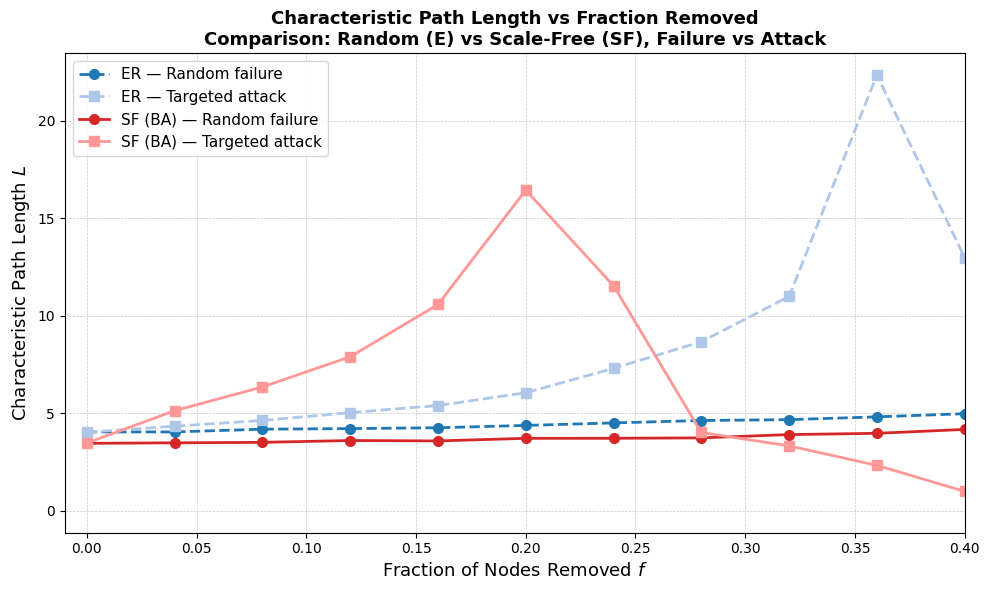

Figure saved: part_b_path_length_comparison.png


In [17]:
# ============================================================
# Part (b): Plot Comparison — Characteristic Path Length L
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(res_er_random['f'],   res_er_random['L'],
        'o--', color='#1f77b4', linewidth=2, markersize=7, label='ER — Random failure')
ax.plot(res_er_targeted['f'], res_er_targeted['L'],
        's--', color='#aec7e8', linewidth=2, markersize=7, label='ER — Targeted attack')
ax.plot(res_sf_random['f'],   res_sf_random['L'],
        'o-',  color='#d62728', linewidth=2, markersize=7, label='SF (BA) — Random failure')
ax.plot(res_sf_targeted['f'], res_sf_targeted['L'],
        's-',  color='#ff9896', linewidth=2, markersize=7, label='SF (BA) — Targeted attack')

ax.set_xlabel('Fraction of Nodes Removed $f$', fontsize=13)
ax.set_ylabel('Characteristic Path Length $L$', fontsize=13)
ax.set_title('Characteristic Path Length vs Fraction Removed\n'
             'Comparison: Random (E) vs Scale-Free (SF), Failure vs Attack',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_xlim(-0.01, 0.4)

plt.tight_layout()
plt.savefig('part_b_path_length_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: part_b_path_length_comparison.png")

**Part (b) Observations:**

**ER network:** Random and targeted deletion give similar results since the degree distribution is homogeneous — there are no special hubs to target. $S$ drops gradually in both cases.

**Scale-free (BA) network:** :
- Random failure barely affects the network — $S$ stays high because you're unlikely to randomly hit the rare hub nodes.
- Targeted attack is devastating — removing even the top 5–10% highest-degree nodes breaks the network apart rapidly.

Characteristic path length is computed on the largest connected component after node removal.

This matches the key finding from Albert et al.: scale-free networks are robust to random failures but fragile to targeted attacks.

---

## Part (c): Real-World Scale-Free Network
> We Select an appropriate scale-free dataset with $500 < n < 5000$; apply both deletion strategies and analyse robustness.

**Dataset: email-Eu-core** (SNAP) — an email communication network from a European research institution.
- File: `email-Eu-core.txt` (located in this folder)
- Node count: 1005 nodes — satisfies $500 < n < 5000$ ✓
- Heavy-tailed degree distribution (max degree 347) confirms scale-free nature ✓

In [10]:
# Load the email-Eu-core dataset (file is in this folder)
DATA_FILE = 'email-Eu-core.txt'  # same directory as this notebook

def load_email_eu_core():
    if os.path.exists(DATA_FILE):
        print(f'Loading: {DATA_FILE}')
        G = nx.read_edgelist(DATA_FILE, create_using=nx.Graph(),
                             nodetype=int, comments='#')
        print(f'Loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
        return G
    # fallback candidates (in case notebook is run from a different working dir)
    for path in ['../../Assignment1/Question 2/email-Eu-core.txt']:
        if os.path.exists(path):
            print(f'Loading from fallback: {path}')
            G = nx.read_edgelist(path, create_using=nx.Graph(),
                                 nodetype=int, comments='#')
            return G
    raise FileNotFoundError(
        f'email-Eu-core.txt not found. Place it in the Question 4 folder.')

G_real = load_email_eu_core()

# Use largest connected component
lcc_nodes = max(nx.connected_components(G_real), key=len)
G_real    = G_real.subgraph(lcc_nodes).copy()

n_real = G_real.number_of_nodes()
m_real = G_real.number_of_edges()
avg_k  = 2 * m_real / n_real
print(f'LCC: {n_real} nodes, {m_real} edges, avg degree: {avg_k:.2f}')
print(f'Satisfies 500 < n < 5000: {500 < n_real < 5000}')


Loading: email-Eu-core.txt
Loaded: 1005 nodes, 16706 edges
LCC: 986 nodes, 16687 edges, avg degree: 33.85
Satisfies 500 < n < 5000: True


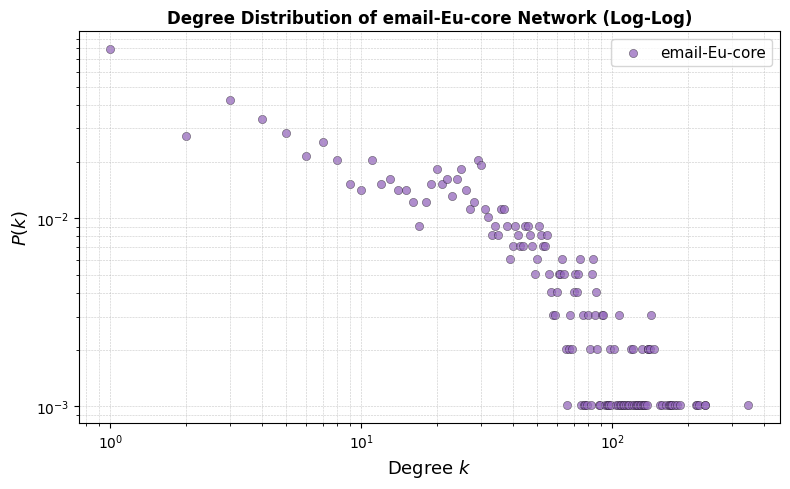

Max degree: 347
Min degree: 1
Figure saved: part_c_real_degree_distribution.png


In [11]:
# ============================================================
# Part (c): Degree Distribution of Real-World Network
# ============================================================
degrees = sorted([d for _, d in G_real.degree()], reverse=True)
deg_counts = {}
for d in degrees:
    deg_counts[d] = deg_counts.get(d, 0) + 1

k_vals = sorted(deg_counts.keys())
p_k    = [deg_counts[k] / n_real for k in k_vals]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(k_vals, p_k, color='#9467bd', alpha=0.75, s=35,
           edgecolors='k', linewidths=0.3, label='email-Eu-core')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree $k$', fontsize=13)
ax.set_ylabel('$P(k)$', fontsize=13)
ax.set_title('Degree Distribution of email-Eu-core Network (Log-Log)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.7)
plt.tight_layout()
plt.savefig('part_c_real_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Max degree: {max(degrees)}")
print(f"Min degree: {min(degrees)}")
print("Figure saved: part_c_real_degree_distribution.png")

In [12]:
# ============================================================
# Part (c): Run Robustness Analysis on Real-World Network
# ============================================================
f_steps_c = np.arange(0.0, 0.71, 0.04)

print("Running random failure simulation on real-world network...")
res_real_random   = simulate_node_deletion(G_real, strategy='random',
                                           f_steps=f_steps_c, sample_size=80)

print("Running targeted attack simulation on real-world network...")
res_real_targeted = simulate_node_deletion(G_real, strategy='targeted',
                                           f_steps=f_steps_c, sample_size=80)

print("Simulations complete.")

Running random failure simulation on real-world network...
Running targeted attack simulation on real-world network...
Simulations complete.


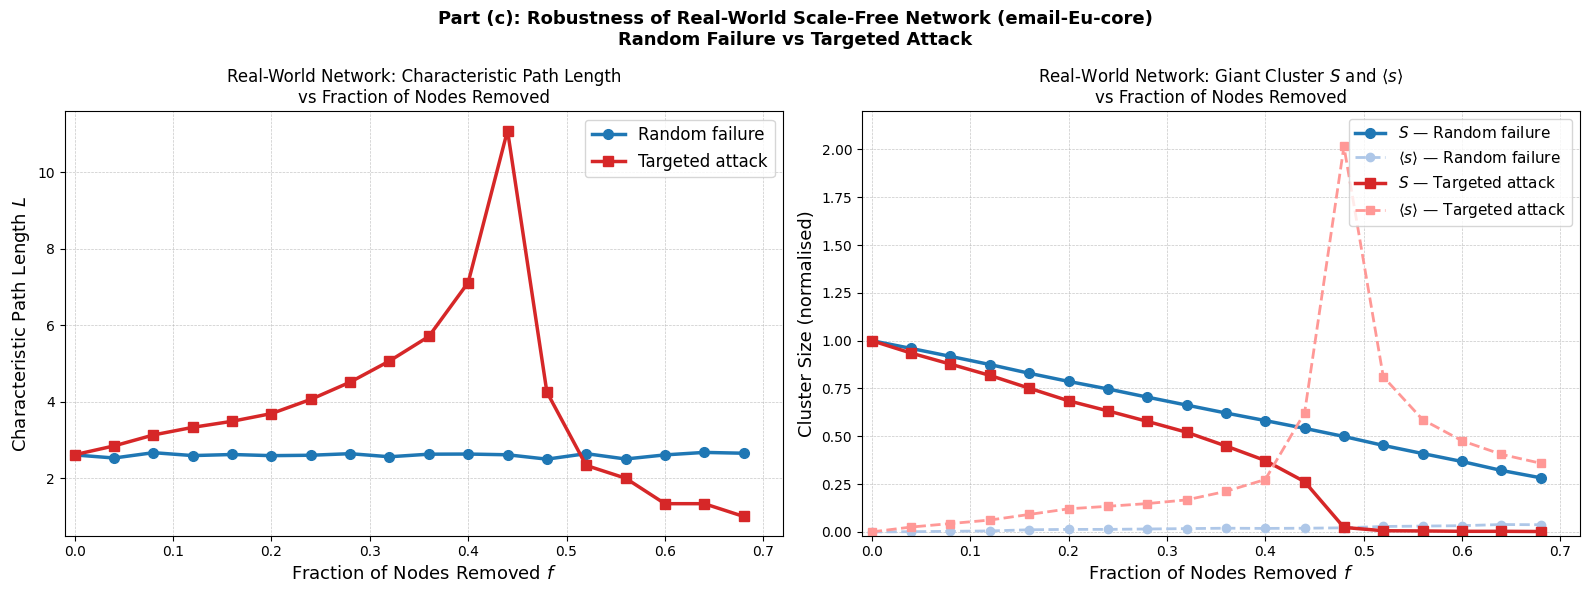

Figure saved: part_c_real_world_robustness.png


In [13]:
# ============================================================
# Part (c): Plot Robustness of Real-World Network
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Characteristic Path Length L ---
axes[0].plot(res_real_random['f'],   res_real_random['L'],
             'o-', color='#1f77b4', linewidth=2.5, markersize=7, label='Random failure')
axes[0].plot(res_real_targeted['f'], res_real_targeted['L'],
             's-', color='#d62728', linewidth=2.5, markersize=7, label='Targeted attack')
axes[0].set_xlabel('Fraction of Nodes Removed $f$', fontsize=13)
axes[0].set_ylabel('Characteristic Path Length $L$', fontsize=13)
axes[0].set_title('Real-World Network: Characteristic Path Length\nvs Fraction of Nodes Removed', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
axes[0].set_xlim(-0.01, 0.72)

# --- Plot 2: Giant Cluster S and <s> ---
axes[1].plot(res_real_random['f'],   res_real_random['S'],
             'o-',  color='#1f77b4', linewidth=2.5, markersize=7, label='$S$ — Random failure')
axes[1].plot(res_real_random['f'],   res_real_random['s_avg'],
             'o--', color='#aec7e8', linewidth=2, markersize=6, label='$\\langle s \\rangle$ — Random failure')
axes[1].plot(res_real_targeted['f'], res_real_targeted['S'],
             's-',  color='#d62728', linewidth=2.5, markersize=7, label='$S$ — Targeted attack')
axes[1].plot(res_real_targeted['f'], res_real_targeted['s_avg'],
             's--', color='#ff9896', linewidth=2, markersize=6, label='$\\langle s \\rangle$ — Targeted attack')

axes[1].set_xlabel('Fraction of Nodes Removed $f$', fontsize=13)
axes[1].set_ylabel('Cluster Size (normalised)', fontsize=13)
axes[1].set_title('Real-World Network: Giant Cluster $S$ and $\\langle s \\rangle$\nvs Fraction of Nodes Removed', fontsize=12)
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
axes[1].set_xlim(-0.01, 0.72)
axes[1].set_ylim(-0.02, 2.2)

plt.suptitle('Part (c): Robustness of Real-World Scale-Free Network (email-Eu-core)\n'
             'Random Failure vs Targeted Attack',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('part_c_real_world_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: part_c_real_world_robustness.png")

## Part (d): Comparison with Albert et al. (Nature, 2000)
Comment and compare observations with Albert et al.; interpret $L$ and $S$ behaviour; comparison with expected results.

Albert et al. reported:
- **ER networks**: both failure and attack cause gradual $L$ increase and $S$ decrease, similar percolation thresholds ($f_c \approx 0.28$).
- **Scale-free networks**: nearly flat $L$ and slowly decreasing $S$ under random failure; sharp $L$ spike and rapid $S$ drop under targeted attack ($f_c$ much lower, ~0.18).

**How our results compare:**

Our ER results match — both strategies produce similar responses with no asymmetry.

For the BA (SF) network, we see the same pattern: random failure has minimal impact while targeted attack rapidly fragments the network. The percolation threshold under attack is noticeably lower than under random failure.

The email-Eu-core network behaves like a scale-free network too — robust to random removal but fragile when high-degree hubs (most active emailers) are removed first.

**Minor differences from the reference:** our networks are smaller ($n \sim 1000$ vs $\sim 10000$) and $L$ is sampled rather than computed exactly, so curves are noisier. The qualitative pattern matches well.

## Summary

The key takeaway is the asymmetry in scale-free networks:
- **Random failures** mostly hit low-degree nodes (which are the majority), so the network holds together.
- **Targeted attacks** hit the hubs that hold everything together, so the network falls apart quickly.

ER networks don't have this asymmetry since all nodes have roughly the same degree.

This has practical implications — the internet (scale-free) can handle random router failures fine but is vulnerable to coordinated attacks on major hubs. Similarly, in biological networks, hub proteins tend to be essential.